In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("dogecoin.csv")
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0   11/9/2017  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0
1  11/10/2017  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0
2  11/11/2017  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0
3  11/12/2017  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0
4  11/13/2017  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0


Exploratory Data Analysis (EDA)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 1760 entries, 0 to 1760
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1760 non-null   str    
 1   Open       1760 non-null   float64
 2   High       1760 non-null   float64
 3   Low        1760 non-null   float64
 4   Close      1760 non-null   float64
 5   Adj Close  1760 non-null   float64
 6   Volume     1760 non-null   float64
dtypes: float64(6), str(1)
memory usage: 125.6 KB


In [11]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


In [12]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [13]:
#  Dropping the null value as it is very less in number and will not affect the model performance
df.dropna(inplace = True)
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [16]:
# Visuasilizing the data to get a better understanding 
# for cols in df.columns:
#     plt.figure(figsize = (10,5))
#     sns.histplot(df[cols],kde = True, bins =100)
#     plt.show()

In [17]:
df.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

In [18]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes

Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

In [20]:
df.corr(numeric_only = True, method = "pearson")

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


<Axes: >

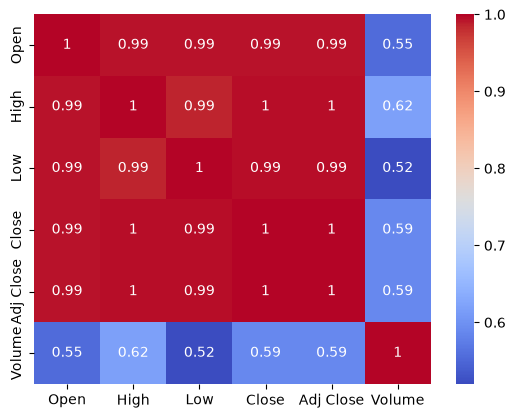

In [ ]:
# Heatmap generation to visualize the correlation between the features 
sns.heatmap(df.corr(numeric_only = True , method = "pearson"),annot = True , cmap = "coolwarm")

In [24]:
# Breaking the dates into year month day
df = df.sort_values('Date')
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0,2017,11,9
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0,2017,11,10
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0,2017,11,11
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0,2017,11,12
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0,2017,11,13


In [49]:
df['Target'] = df['Close'].shift(-1)
print(df.head())

        Date      Open      High       Low     Close  Adj Close     Volume  \
0 2017-11-09  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0   
1 2017-11-10  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0   
2 2017-11-11  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0   
3 2017-11-12  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0   
4 2017-11-13  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0   

   Year  Month  Day    Target  
0  2017     11    9  0.001163  
1  2017     11   10  0.001201  
2  2017     11   11  0.001038  
3  2017     11   12  0.001211  
4  2017     11   13  0.001184  


In [63]:
# Model selection and training
df = df.dropna().reset_index(drop=True)
X = df.drop(['Date','Target'], axis = 1)
y = df['Target']
print(X.head())
print(y.head())

       Open      High       Low     Close  Adj Close     Volume  Year  Month  \
0  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0  2017     11   
1  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0  2017     11   
2  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0  2017     11   
3  0.001189  0.001210  0.001002  0.001038   0.001038  3288960.0  2017     11   
4  0.001046  0.001212  0.001019  0.001211   0.001211  2481270.0  2017     11   

   Day  
0    9  
1   10  
2   11  
3   12  
4   13  
0    0.001163
1    0.001201
2    0.001038
3    0.001211
4    0.001184
Name: Target, dtype: float64


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [73]:
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
# model = LinearRegression() , very poor accuracy
model.fit(X_train,y_train)
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [74]:
y_pred = model.predict(X_test)
y_pred

array([0.00323526, 0.00291114, 0.28815729, 0.16886974, 0.00444709,
       0.00327797, 0.14896836, 0.00589107, 0.23501132, 0.00496139,
       0.00867666, 0.0027056 , 0.00209387, 0.00351137, 0.00237839,
       0.00250984, 0.00220254, 0.00421191, 0.21418622, 0.00556878,
       0.00607887, 0.00200061, 0.17412537, 0.00274939, 0.00189831,
       0.00256058, 0.00288289, 0.2259132 , 0.00269457, 0.00438387,
       0.06881683, 0.00237924, 0.06847253, 0.00827853, 0.00300362,
       0.00333639, 0.00290671, 0.00559592, 0.11705292, 0.00585301,
       0.06064373, 0.01245957, 0.00354809, 0.50650413, 0.00329358,
       0.06786695, 0.14017742, 0.00277371, 0.21235522, 0.00343564,
       0.00263034, 0.34556069, 0.00257007, 0.13220936, 0.06253659,
       0.00212014, 0.12255655, 0.04845634, 0.06920465, 0.00199839,
       0.00216137, 0.00360861, 0.00317997, 0.0020209 , 0.06196433,
       0.00243699, 0.00243076, 0.25182226, 0.05618002, 0.00251458,
       0.00299959, 0.00244149, 0.27099672, 0.00305872, 0.00305

In [75]:
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
P = X_test.shape[1]
adjusted_r2 = 1- ((1 - r2)*(n-1) / (n - P - 1))

print("R2 Score: ",r2)
print("Adjusted R2 Score: ",adjusted_r2)

R2 Score:  0.9699205784541685
Adjusted R2 Score:  0.9691290147292781


In [76]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score: ",r2)

MAE : 0.004676465397727265
MSE : 0.00033609317775879286
RMSE: 0.018332844235382378
R2 Score:  0.9699205784541685
